# NL-1 — Test-time learning: TTT → Titans → Atlas → Miras

**The question:** what if the hidden state is itself a model, trained at inference?

First module of the Nested Learning track. Prerequisites: foundations M1–M7. Runs on CPU in seconds; PyTorch throughout. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/nested-learning/nl1-test-time-learning.ipynb)

[M7](../../foundations/m7-three-dials.ipynb) left the write rule as a **formula**: hand it a key and a value, and it produces the vector that goes into the memory. Four papers break the formula open by making the write *gradient descent on a loss* — and once it is, the memory can be a whole model and the write can be a whole optimizer:

- **TTT** — the hidden state *is* a model $f_W$; the write is a GD step on a self-supervised loss.
- **Titans** — make that write an optimizer: momentum on "surprise" + an adaptive forgetting gate.
- **Atlas** — memorize a *window* of context (the Omega rule), with a Muon-style update.
- **Miras** — the unifying frame: every such model is a choice of *(architecture, objective, retention, optimizer)*.

> **Prerequisite math** — *singular values* and *Newton–Schulz whitening* ($\kappa\to1$), which §3 below needs for Atlas' update, are in the [linear-algebra primer](../../primers/linear-algebra.ipynb) §2.


## Objective

After this module you should be able to:

- State the TTT thesis — *the hidden state is a model $f_W$, the write is $W_t=W_{t-1}-\eta\nabla\ell(W_{t-1};x_t)$ on a self-supervised loss* — and show that a **linear** $f_W$ with one step **is** M4's delta write, so TTT contains DeltaNet as a special case.
- Explain why a **deep** memory (MLP) stores more than a linear one, and where that capacity comes from.
- Write **Titans'** update $M_t=(1-\alpha_t)M_{t-1}+S_t,\ S_t=\eta_t S_{t-1}-\theta_t\nabla\ell$, and say what the **momentum** ("past surprise") and **forgetting** $\alpha_t$ terms each buy.
- Describe **Atlas'** two additions — the **Omega rule** (memorize a window, not one token) and the **Muon / Newton–Schulz** update.
- State **Miras'** four axes — *memory architecture · attentional bias · retention gate · memory learning algorithm* — and place linear attention, DeltaNet, TTT and Titans as points in that space.
- Say what this track does to [M7](../../foundations/m7-three-dials.ipynb)'s three dials: the write rule stops being a formula, the optimizer moves inside the forward pass, and the gate — $1$ in every sequence memory the foundations built — finally turns.


## Why it exists (the limitation it removes)

[M7](../../foundations/m7-three-dials.ipynb) left the write rule as a formula: given a key and a value, produce what goes in the memory. Hebbian hands the value in raw; delta subtracts what the memory already returns. Either way the answer is a closed-form expression you can write on one line, and the memory it writes into is a **matrix**. Two ceilings come with that:

- **Shallow capacity.** A $d\times d$ matrix resolves $\sim d$ associations ([M2](../../foundations/m2-fast-weight-programmers.ipynb) §4's capacity law), and a linear map can only represent *linear* key→value mappings.
- **A one-shot, fixed write.** Each token gets exactly one correction. There is no notion of *optimizing* the memory — no multiple steps, no momentum, no second-order information, no choice of objective.

TTT asks the question that breaks the formula open: what if the write rule is **gradient descent on a loss**, and the memory is a model being trained while the sequence runs? Both ceilings lift at once. If the hidden state is a *model* $f_W$ — an MLP, not just a matrix — the memory can be deep and nonlinear; if the write is a gradient step, it can become a *real optimization process*, with as many steps, as much momentum, and as free a choice of objective as you like.

Which collapses the last distance between M6's two levels. [M6](../../foundations/m6-optimizers-as-memory.ipynb) established that an optimizer *is* a memory over the gradient stream — but it ran that argument entirely inside the training script, with the optimizer still a thing that moves the model from outside. Here the optimizer you built there becomes **part of the forward pass** — the machinery that writes the sequence memory, one level up from the weights it used to move. The cost is compute (you train a model every forward pass), which is why this line of work is also, always, about doing it *efficiently and in parallel*.


## Core idea — the memory is a model you train at inference

One sentence ([TTT](https://arxiv.org/abs/2407.04620), Sun et al. 2024): **make the hidden state a model $f_W$, and the update rule a gradient step on a self-supervised loss $\ell$** — so, in the paper's words, *"updating the hidden state on a test sequence is equivalent to training the model $f$ at test time"* (Figure 1). The associative loss is the same one M4 used, now for an arbitrary $f_W$:

$$\ell(W;x_t)=\big\lVert f_W(\mathbf{k}_t)-\mathbf{v}_t\big\rVert^2,\qquad \boxed{\,W_t=W_{t-1}-\eta\,\nabla_W\ell(W_{t-1};x_t)\,},\qquad \mathbf{y}_t=f_{W_t}(\mathbf{q}_t).$$

*(Notation note: TTT writes these views as $\theta_K x_t$, $\theta_V x_t$, $\theta_Q x_t$ — its "training / label / test view" (§2.3, Eq. 4–5). We keep this course's $\mathbf{k},\mathbf{v},\mathbf{q}$, which is also Titans' own notation, so the M1–M7 recurrence stays legible across the track.)*

With $f_W(\mathbf{k})=W\mathbf{k}$ and one step at $\eta=\tfrac12$, this is **exactly M4's delta write** $W+(\mathbf{v}-W\mathbf{k})\mathbf{k}^\top$ — the first cell checks it. TTT makes the same connection from its own side: DeltaNet *"is equivalent to TTT-Linear with inner-loop mini-batch size 1, without the Layer Norm and residual connection"* (§4.2). Everything that follows turns dials on this one equation:

| paper | what it turns | result |
|---|---|---|
| **TTT** | $f_W$: linear → **MLP**; 1 → **many** steps | deep memory, multi-step write |
| **Titans** | the step → **GD + momentum + weight-decay** | "surprise" with memory + adaptive **forgetting** |
| **Atlas** | objective over **one token → a window**; GD → **Muon** | higher capacity, ~2nd-order write |
| **Miras** | names the axes: *architecture · objective · retention · optimizer* | the whole design space |

### Reading

- [TTT](https://arxiv.org/abs/2407.04620) — §2.1 (Eq. 2, the GD-step update), §2.3 (Eq. 4, the multi-view self-supervised loss; Eq. 5, the output rule), §2.6 (Theorem 1: a linear $f$ with **batch** GD at $\eta=\tfrac12$ from $W_0=0$ **is** linear attention), §2.7 (TTT-Linear vs TTT-MLP). Primary for §1.
- [Titans](https://arxiv.org/abs/2501.00663) — §3.1: Eq. 12 (the associative loss), Eqs. 9–10 (surprise + momentum), Eqs. 13–14 (the forgetting gate), and the deep MLP memory. Primary for §2.
- [Atlas](https://arxiv.org/abs/2505.23735) — §3.2 (Eq. 9, the Omega rule; Eq. 10, OmegaNet), §3.1 (polynomial feature maps for capacity), §5 (Eqs. 32–33, Muon / Newton–Schulz). Primary for §3.
- [Miras](https://arxiv.org/abs/2504.13173) — §1 and §4 (the four axes), Definition 3.1 ("attentional bias"), Table 1 (prior models placed in the space), §5.3 (the Moneta / Yaad / Memora instances). Primary for §4.


## 1. TTT — the hidden state is a model, the write is a gradient step

The cleanest form. Instead of *adding* an outer product to a matrix, we *take a gradient step* on the associative loss $\ell(W;x_t)=\lVert f_W(\mathbf{k}_t)-\mathbf{v}_t\rVert^2$ — for **any** model $f_W$. The first cell checks the bridge to M4: a *linear* $f_W$ with **one** step is the delta rule, to floating-point tolerance.

Both of the foundations' linear memories are down there, and the dial between them is the *number of steps*. One step on $\ell$ gives $W+(\mathbf{v}-W\mathbf{k})\mathbf{k}^\top$ — [M4](../../foundations/m4-delta-rule.ipynb)'s delta write, a DeltaNet. **Batch** GD from $W_0=0$ gives $W_t=\sum_s \mathbf{v}_s\mathbf{k}_s^\top$ — [M3](../../foundations/m3-linear-attention.ipynb)'s linear attention, which is TTT's own Theorem 1 (§2.6). Same $f_W$, same $\eta=\tfrac12$, different optimizer, and the two modules M4 spent its length separating fall out of the same equation. That is the dial this whole track turns.


In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

torch.manual_seed(0)
d = 8
k = F.normalize(torch.randn(d), dim=0)
v = torch.randn(d)

# M4 delta write (beta=1, unit key):  W + (v - W k) k^T
W0 = torch.zeros(d, d)
delta = W0 + torch.outer(v - W0 @ k, k)

# TTT-Linear: one GD step on  l = ||W k - v||^2,  grad = 2(Wk - v)k^T,  step eta=1/2
W = W0.clone().requires_grad_(True)
loss = ((W @ k - v) ** 2).sum()
g = torch.autograd.grad(loss, W)[0]
ttt = (W - 0.5 * g).detach()

print(
    "TTT-Linear (1 step, eta=1/2)  ==  M4 delta rule :",
    torch.allclose(delta, ttt, atol=1e-6),
)
print("=> TTT *generalizes* the delta rule: memory = a model f_W, write = a GD step on ||f_W(k)-v||^2.")
print("   linear f_W + 1 step recovers M4's delta rule (batch GD instead gives M3's linear attention);")
print("   an MLP f_W or >1 step goes beyond both.")

TTT-Linear (1 step, eta=1/2)  ==  M4 delta rule : True
=> TTT *generalizes* the delta rule: memory = a model f_W, write = a GD step on ||f_W(k)-v||^2.
   linear f_W + 1 step recovers M4's delta rule (batch GD instead gives M3's linear attention);
   an MLP f_W or >1 step goes beyond both.


::: {.callout-note collapse="true"}
## Q: It's "self-supervised," but at test time we have no labels. Where does the error signal come from?

From the data, at **two levels** — and the inner one needs no labels at all.

- **Inner loss (self-supervised, test time, no labels).** The target is a *view of the input token itself*: $\mathbf{k}_t=\theta_K x_t$, $\mathbf{v}_t=\theta_V x_t$, and $\ell=\lVert f_W(\mathbf{k}_t)-\mathbf{v}_t\rVert^2$ (TTT §2.3, Eq. 4). The "label" $\mathbf{v}_t$ is a projection of $x_t$, not external supervision; the error is just how badly the memory reproduces one view of the token from another — Titans' "surprise." Well-defined with zero ground truth, and this is what runs at test time. (M4 made the same move: the delta write's target $\mathbf{v}_t=W_V x_t$ was *also* a projection of the input, never a label.)
- **Outer loss (supervised, training only, real labels).** A separate task loss with ground truth runs during training and shapes $\theta_K,\theta_V$ — it decides *what views are worth memorizing* so that the label-free inner loop is useful for the real task.

So labels are never needed at test time; they did their work earlier, in the outer loop, choosing what the self-supervision should target. It's **meta-learning**: the outer loop configures a self-supervised inner loop. (The one twist over [M5](../../foundations/m5-meta-learning-self-reference.ipynb)'s MAML — whose inner loop adapts on a *labeled* support set — is that TTT's inner objective is self-supervised, so test-time adaptation needs *zero* labels.)

Two asides work this end to end, and exist to answer exactly this question:

- [where the self-supervised error comes from](nl1-aside-self-supervision.ipynb) — the *abstract* version: a toy where the **same** label-free inner loop is useless with random projections and works once the outer loss has trained them (recall error $\approx 1.2 \to 0.23$).
- [test-time training you can see](nl1-aside-image-ttt.ipynb) — the *tangible* version: the original image Test-Time Training, where predicting **self-applied rotations** (a free label) claws back much of the accuracy corruption destroys ($0.11\to0.53$, against $0.98$ clean) using **zero class labels**.

A second, even more intuitive flavor of the same principle: in next-token prediction the future of the stream is the label for its past — the sequence supervises itself one step late.
:::


### Deep memory beats a matrix

Why bother making $f_W$ an MLP? Capacity. A linear memory (a matrix) resolves $\sim d$ associations and can only fit *linear* key→value maps (M2's law). A **deep** memory has more parameters and nonlinearity, so it stores more. We "train the memory at test time" — fit $f_W$ to a whole set of $N$ associations by gradient descent — and compare a linear vs an MLP backbone as $N$ grows past the matrix capacity $d$.

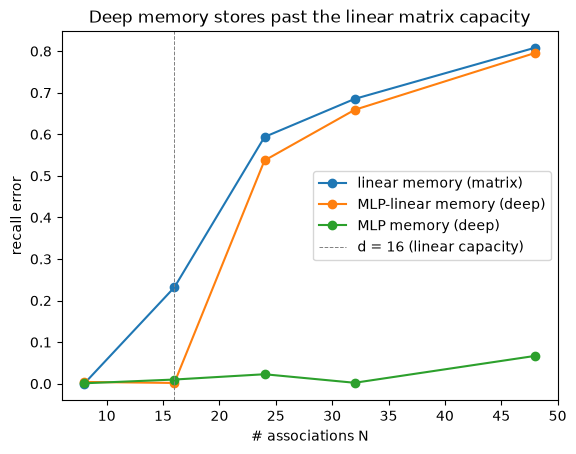

at N=32:  linear recall err 0.69   MLP 0.00  -> the MLP memory is far from saturating.


In [2]:
def fit_recall(N, backbone, d=16, h=64, steps=300, lr=0.1, seed=0):
    g = torch.Generator().manual_seed(seed)
    K = F.normalize(torch.randn(N, d, generator=g), dim=1)
    V = torch.randn(N, d, generator=g)
    if backbone == "linear":
        P = [torch.zeros(d, d, requires_grad=True)]
        f = lambda P, x: x @ P[0].t()
    elif backbone == "mlp-linear":
        P = [
            (torch.randn(h, d, generator=g) * math.sqrt(2 / d)).requires_grad_(True),
            torch.zeros(h, requires_grad=True),
            (torch.randn(d, h, generator=g) * math.sqrt(2 / h)).requires_grad_(True),
            torch.zeros(d, requires_grad=True),
        ]
        f = lambda P, x: (x @ P[0].t() + P[1]) @ P[2].t() + P[3]
    else:  # 1-hidden-layer MLP memory (deep memory)
        P = [
            (torch.randn(h, d, generator=g) * math.sqrt(2 / d)).requires_grad_(True),
            torch.zeros(h, requires_grad=True),
            (torch.randn(d, h, generator=g) * math.sqrt(2 / h)).requires_grad_(True),
            torch.zeros(d, requires_grad=True),
        ]
        f = lambda P, x: F.relu(x @ P[0].t() + P[1]) @ P[2].t() + P[3]
    opt = torch.optim.Adam(P, lr=lr)
    for _ in range(steps):  # test-time training of the memory on N pairs
        opt.zero_grad()
        (((f(P, K) - V) ** 2).sum(1).mean()).backward()
        opt.step()
    return ((f(P, K) - V).norm(dim=1) / V.norm(dim=1)).mean().item()


Ns = [8, 16, 24, 32, 48]
lin = [fit_recall(N, "linear") for N in Ns]
mlp_lin = [fit_recall(N, "mlp-linear") for N in Ns]
mlp = [fit_recall(N, "mlp") for N in Ns]
plt.plot(Ns, lin, marker="o", label="linear memory (matrix)")
plt.plot(Ns, mlp_lin, marker="o", label="MLP-linear memory (deep)")
plt.plot(Ns, mlp, marker="o", label="MLP memory (deep)")
plt.axvline(16, ls="--", c="gray", lw=0.7, label="d = 16 (linear capacity)")
plt.xlabel("# associations N")
plt.ylabel("recall error")
plt.legend()
plt.title("Deep memory stores past the linear matrix capacity")
plt.show()
print(f"at N=32:  linear recall err {lin[3]:.2f}   MLP {mlp[3]:.2f}  -> the MLP memory is far from saturating.")

## 2. Titans — make the write an optimizer (momentum + forgetting)

TTT takes *one plain* gradient step per token. **Titans** (Behrouz et al.) turns the write into a proper optimizer over the same associative loss (§3.1, Eq. 12), adding two terms — momentum (Eqs. 9–10) and a forgetting gate (Eqs. 13–14):

$$\boxed{\,M_t=(1-\alpha_t)\,M_{t-1}+S_t,\qquad S_t=\eta_t\,S_{t-1}-\theta_t\,\nabla\ell(M_{t-1};x_t)\,}$$

- $\nabla\ell$ is the **"momentary surprise"** — how wrong the memory is on this token (large gradient = surprising input).
- $\eta_t S_{t-1}$ is **momentum**, what Titans calls **"past surprise"** — surprise accumulated over recent tokens. It's exactly SGD-momentum on the inner loss. Note $\eta_t$ is the *decay* on that accumulator, not a step size; $\theta_t$ is the actual (data-dependent) learning rate on the gradient.
- $(1-\alpha_t)$ is an **adaptive forgetting** gate — data-dependent weight decay. Titans shows *"this weight decay mechanism is closely related to the gating mechanism in modern RNNs"* (§3.1).

So the write is *gradient descent with momentum and weight decay* — an **optimizer running in the forward pass**. And note which dial that forgetting gate turns: it is M7 §3's $\alpha_t$, which reads $1$ in every sequence memory of the foundations. M6 does decay a memory — but its $\alpha$ fades a *momentum buffer*, one level down. Titans is the first memory *over tokens* in this course built to forget. Two cells show what each new term buys.


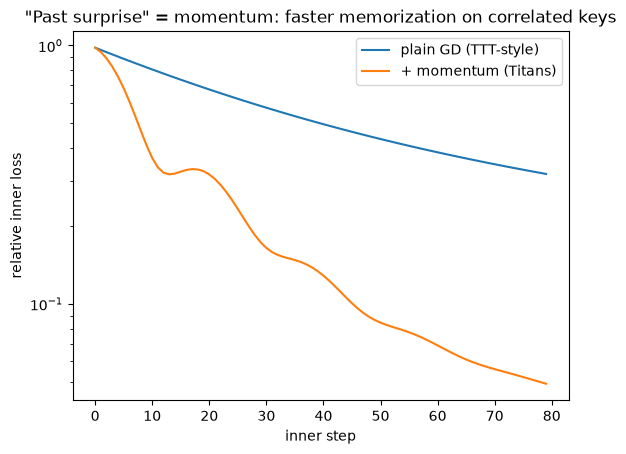

steps to reach <0.1 relative loss:  plain GD >80,  +momentum 46.


In [3]:
# Momentum ("past surprise") accelerates the inner optimization on ill-conditioned keys.
torch.manual_seed(0)
d = 16
g = torch.Generator().manual_seed(1)
K = F.normalize(torch.randn(20, d, generator=g), dim=1)
U, S_, Vt = torch.linalg.svd(K, full_matrices=False)
K = (U * torch.linspace(1.0, 0.15, len(S_))) @ Vt  # ill-condition
Mtrue = torch.randn(d, d)
V = (Mtrue @ K.t()).t()  # reachable target -> loss can hit 0


def descend(momentum, steps=80, lr=0.3):
    M = torch.zeros(d, d)
    Z = torch.zeros(d, d)
    curve = []
    for _ in range(steps):
        grad = (
            2 * (M @ K.t() - V.t()) @ K / len(K)
        )  # surprise = grad of mean ||Mk-v||^2
        Z = momentum * Z - lr * grad  # S_t = eta S_{t-1} - theta grad
        M = M + Z
        curve.append(((M @ K.t() - V.t()).norm() / V.norm()).item())
    return curve


gd, mom = descend(0.0), descend(0.9)
plt.plot(gd, label="plain GD (TTT-style)")
plt.plot(mom, label="+ momentum (Titans)")
plt.yscale("log")
plt.xlabel("inner step")
plt.ylabel("relative inner loss")
plt.legend()
plt.title('"Past surprise" = momentum: faster memorization on correlated keys')
plt.show()
hit = lambda c: next((i for i, x in enumerate(c) if x < 0.1), ">80")
print(f"steps to reach <0.1 relative loss:  plain GD {hit(gd)},  +momentum {hit(mom)}.")

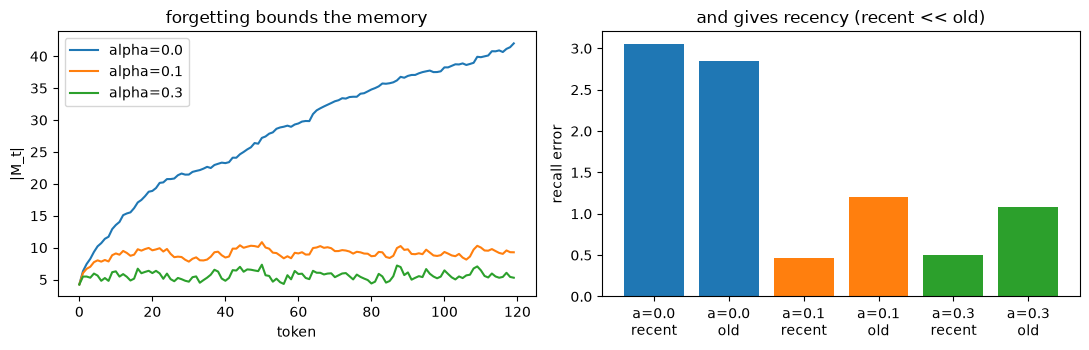

alpha=0: |M| blows up, everything interferes. alpha>0: |M| bounded, recent associations stay recallable.


In [4]:
# Forgetting bounds the memory and creates recency (overcapacity stream of 120 associations).
g = torch.Generator().manual_seed(2)
N = 120
stream = [
    (F.normalize(torch.randn(d, generator=g), dim=0), torch.randn(d, generator=g))
    for _ in range(N)
]


def run_forget(alpha):
    M = torch.zeros(d, d)
    norms = []
    for kk, vv in stream:
        M = (1 - alpha) * M + torch.outer(vv, kk)  # write + (1 - alpha) forget gate
        norms.append(M.norm().item())
    rec = lambda ago: (
        (M @ stream[-ago][0] - stream[-ago][1]).norm().item()
        / stream[-ago][1].norm().item()
    )
    recent = sum(rec(a) for a in range(1, 6)) / 5
    old = sum(rec(a) for a in range(40, 46)) / 6
    return norms, recent, old


fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))
for alpha in (0.0, 0.1, 0.3):
    norms, recent, old = run_forget(alpha)
    axL.plot(norms, label=f"alpha={alpha}")
    axR.bar([f"a={alpha}\nrecent", f"a={alpha}\nold"], [recent, old])
axL.set_xlabel("token")
axL.set_ylabel("|M_t|")
axL.set_title("forgetting bounds the memory")
axL.legend()
axR.set_ylabel("recall error")
axR.set_title("and gives recency (recent << old)")
plt.tight_layout()
plt.show()
print(
    "alpha=0: |M| blows up, everything interferes. alpha>0: |M| bounded, recent associations stay recallable."
)

## 3. Atlas — memorize a *window*, with a Muon-style step

Titans still memorizes **one token at a time**. **Atlas** (Behrouz et al.) adds two things:

1. **The Omega rule** (§3.2, Eq. 9) — optimize the memory over a *sliding window* of the last $c$ tokens jointly, not just the current one:
   $$\min_{\mathcal M}\ \sum_{i=t-c+1}^{t}\gamma_i^{(t)}\,\lVert \mathcal M(\mathbf{k}_i)-\mathbf{v}_i\rVert_2^2,$$
   where the input-dependent $\gamma_i^{(t)}\in[0,1]$ *"act as hard (direct) gates for the past tokens,"* pruning the window in context. Atlas is explicit about the two extremes: *"(1) $c=1$: the update rule becomes online (Delta rule); and (2) $c=\infty$ or context length: the update becomes global optimization w.r.t. all past tokens."* Atlas' own model, **OmegaNet**, adds polynomial feature maps $\phi$ on the keys and queries for capacity (§3.1) — those enter at Eq. 10, the update rule, not in the objective above.
2. **A Muon-style update** (§5, Eqs. 32–33) — replace plain GD with momentum followed by **Newton–Schulz** orthogonalization of the update:
   $$\mathcal M_t=\alpha_t\,\mathcal M_{t-1}-\eta_t\,\mathrm{NS}_k(\mathcal S_t),\qquad \mathcal S_t=\theta_t\,\mathcal S_{t-1}+\nabla\!\!\sum_{i=t-c+1}^{t}\gamma_i^{(t)}\lVert \mathcal M(\phi(\mathbf{k}_i))-\mathbf{v}_i\rVert_2^2.$$
   As the iteration deepens, $\mathrm{NS}_k$ pushes the update toward a semi-orthogonal matrix — *whitening* it. Atlas is careful about the claim, and so are we: Muon *"not only approximates second-order information, but it also mostly leverages matrix multiplication and can be parallelized across the sequence."* Approximate second-order information, not a second-order method. It is the same $\kappa\to1$ cure as the [linear-algebra primer](../../primers/linear-algebra.ipynb) §2, and the same Newton–Schulz [M6](../../foundations/m6-optimizers-as-memory.ipynb) §4 met in Muon — there applied to the *gradient* memory, here to the *sequence* memory.

The cell shows both: Newton–Schulz driving an update's singular values toward 1, and a window ($c{=}8$) retaining correlated context that single-token writes ($c{=}1$) forget.


In [5]:
# (a) Newton-Schulz orthogonalization -- the Muon step. Pushes all singular values toward 1.
def newton_schulz(G, steps=5):
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G / (G.norm() + 1e-7)
    for _ in range(steps):
        A = X @ X.t()
        X = a * X + (b * A + c * A @ A) @ X
    return X


torch.manual_seed(3)
G = torch.randn(d, d) @ torch.diag(
    torch.linspace(0.1, 3.0, d)
)  # an ill-conditioned update
sv_before = torch.linalg.svdvals(G)
sv_after = torch.linalg.svdvals(newton_schulz(G))
print(
    f"Newton-Schulz: singular values  before [{sv_before.min():.2f}, {sv_before.max():.2f}]"
    f"  ->  after [{sv_after.min():.2f}, {sv_after.max():.2f}]  (whitened ~ approx 2nd-order)"
)

# (b) Omega rule: memorize a window of c tokens jointly vs one at a time (correlated keys).
g = torch.Generator().manual_seed(4)
basis = F.normalize(torch.randn(5, d, generator=g), dim=1)
toks = [
    (
        F.normalize(torch.randn(5, generator=g) @ basis, dim=0),
        torch.randn(d, generator=g),
    )
    for _ in range(8)
]


def omega(c, lr=0.15, steps=80):
    M = torch.zeros(d, d)
    for t in range(len(toks)):
        win = toks[max(0, t - c + 1) : t + 1]
        Wp = M.clone().requires_grad_(True)
        for _ in range(steps):
            L = sum(((Wp @ kk - vv) ** 2).sum() for kk, vv in win) / len(win)
            Wp = Wp - lr * torch.autograd.grad(L, Wp)[0]
        M = Wp.detach()
    return (sum((M @ kk - vv).norm() / vv.norm() for kk, vv in toks) / len(toks)).item()


print(
    f"Omega rule, recall over all 8 correlated tokens:  c=1 (single) {omega(1):.2f}   c=8 (window) {omega(8):.2f}"
)

Newton-Schulz: singular values  before [0.09, 17.73]  ->  after [0.69, 1.14]  (whitened ~ approx 2nd-order)


Omega rule, recall over all 8 correlated tokens:  c=1 (single) 0.87   c=8 (window) 0.65


## 4. Miras — it's all one design space

**Miras** (Behrouz et al.) steps back and says: *every* model above (and linear attention, DeltaNet, even softmax attention) is a choice along **four axes** (§1, §4; summarized in its Table 1):

1. **Memory architecture** — what $f_W$ is (vector / matrix / MLP / feature-mapped).
2. **Attentional bias** — the *inner objective* the memory minimizes. Miras makes this a definition: learning the memory's mapping is based on *"an objective $\mathcal L$, called Attentional Bias, that determines the type of memory and its tendency to prioritize some events"* (Definition 3.1). L2, $\ell_p$, Huber, softmax — this is what to memorize and how to weight events.
3. **Retention gate** — how the past is kept vs. decayed (forgetting reframed as a *retention regularizer* $\mathcal R(\cdot)$).
4. **Memory learning algorithm** — the optimizer that minimizes the inner objective (GD, GD+momentum, Muon, or a closed-form/non-parametric solution).

That is [M7](../../foundations/m7-three-dials.ipynb)'s three dials, completed: write rule (here split into *architecture* + *objective*), gate (*retention*), and optimizer. Miras' addition to the hub's frame is that it makes the **objective** a first-class axis, where M7's table only ever named the write rules that fall out of one.

Where this bites: the **attentional bias** is a free choice, and L2 is not always best. Miras says so directly — the L2 objective *"is known to be sensitive to outliers and extreme samples … drawing motivation from robust regression literature, we suggest utilizing the Huber loss-type"* (§5.1) — and builds **Yaad**, a Huber-bias instance (§5.3; its siblings **Moneta** and **Memora** turn the $\ell_p$ and KL-retention dials instead). The cell below is our own illustration of that claim, not a figure from the paper: swap L2 for a Huber loss, feed one outlier token, and watch the L2 memory get corrupted while the robust one shrugs it off.


In [6]:
# Attentional bias as a dial: L2 vs Huber inner loss, with one outlier value in the context.
def fit_bias(kind, d=16, steps=400, lr=0.05, seed=3):
    g = torch.Generator().manual_seed(seed)
    K = F.normalize(torch.randn(8, d, generator=g), dim=1)
    V = torch.randn(8, d, generator=g)
    Ko = F.normalize(torch.randn(1, d, generator=g), dim=1)
    Vo = torch.randn(1, d, generator=g) * 30  # OUTLIER
    Kall, Vall = torch.cat([K, Ko]), torch.cat([V, Vo])
    W = torch.zeros(d, d, requires_grad=True)
    opt = torch.optim.Adam([W], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        pred = Kall @ W.t()
        L = (
            ((pred - Vall) ** 2).sum(1).mean()
            if kind == "l2"
            else F.huber_loss(pred, Vall, delta=1.0) * d
        )
        L.backward()
        opt.step()
    return (
        ((K @ W.t().detach() - V).norm(dim=1) / V.norm(dim=1)).mean().item()
    )  # recall on CLEAN keys


print(
    f"recall error on the 8 CLEAN keys after one outlier:  L2 bias {fit_bias('l2'):.2f}   Huber bias {fit_bias('huber'):.2f}"
)
print(
    "L2's gradient scales with the (huge) outlier residual -> it distorts the whole memory;"
)
print(
    "Huber clips that gradient -> the clean associations survive. The inner objective is a design choice."
)

recall error on the 8 CLEAN keys after one outlier:  L2 bias 0.30   Huber bias 0.00
L2's gradient scales with the (huge) outlier residual -> it distorts the whole memory;
Huber clips that gradient -> the clean associations survive. The inner objective is a design choice.


## 5. Synthesis — the write rule is an optimizer at test time

Read NL-1 back as one sentence: **the memory's update is an optimization process running in the forward pass.** TTT = one GD step; Titans = GD + momentum + weight-decay; Atlas = windowed objective + Newton–Schulz. The *objective*, the *gate*, and the *optimizer* are all dials — which is precisely Miras' design space, and precisely [M7](../../foundations/m7-three-dials.ipynb)'s three dials with the write rule pulled apart into architecture and objective.

**What this does to M6's table.** [M6](../../foundations/m6-optimizers-as-memory.ipynb) §5 set the sequence memory and the optimizer side by side and found its last three rows blank on the sequence side — deep, non-linear and preconditioned memories that the optimizer column had and the foundations' sequence models did not. That was a statement about the foundations, not about the world, and this module is where two of the three fill in:

| | sequence memory (M1–M5) | sequence memory (this module) | optimizer (M6) |
|---|---|---|---|
| deeper memory | — | **TTT-MLP** (TTT §2.7); Titans' MLP memory (Titans §3.1) | DMGD (MLP buffer) |
| non-linear output | — | **Atlas' Newton–Schulz on the update** (Atlas §5, Eqs. 32–33); TTT wrapping its memory as $f(x)=x+\mathrm{LN}(f_{\text{res}}(x))$ (TTT §2.7) | Muon (Newton–Schulz) |
| preconditioned | — | — | Adam / AdaGrad / Shampoo |

Two things worth reading off it. **The Newton–Schulz row is the same trick on both sides** — M6 filed Muon as a non-linearity on the *gradient* memory's output; Atlas puts the identical iteration on the *sequence* memory's update. Note its double life: its motive belongs to the row below it (Atlas adopts it because it *"approximates second-order information"*), but its mechanism is a non-linearity, which is exactly how M6 filed it one level down.

**And the last row is still a dash on the sequence side** — which is the interesting one. Nothing in this lineage preconditions the sequence memory the way Adam preconditions weights: TTT and Miras' instances descend plainly, Titans adds momentum, Atlas orthogonalizes. The optimizer column solved that problem decades ago. That the transfer has not been made is a gap, not a law.

**Where the track goes next.** M6 found a memory inside the optimizer; NL-1 put an optimizer inside the memory. Neither result is the interesting one alone — the interesting one is that they are the *same* result, and that nothing stops it at two. The inner test-time optimization and the outer training run are two **levels**, updating at different rates; nothing says a model gets only two. Order every changing part of a model by update frequency and you get [NL-2](nl2-levels-continuum-memory.ipynb)'s continuum — and, at the end of it, [HOPE](nl3-hope.ipynb).


## Code walkthrough — test-time learning in real code

- **[TTT](https://github.com/test-time-training/ttt-lm-pytorch)** — the released layer is our §1 loop, mini-batched (a chunk of tokens per inner step for parallelism) with $f_{\text{res}}$ = TTT-Linear or TTT-MLP, wrapped as $f(x)=x+\mathrm{LN}(f_{\text{res}}(x))$. The multi-view projections $\theta_K,\theta_V,\theta_Q$ are the outer-loop (slow) weights; $W$ is the fast memory.
- [`titan/self_modifying.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/titan/self_modifying.py) in [kmccleary3301/nested_learning](https://github.com/kmccleary3301/nested_learning) — this module taken literally, and then one step further. The memory is a **residual MLP** (§1's deep memory), written by `torch.func.grad` *inside the forward pass* with `momentum` and an optional rank-1 preconditioner (§2, §3). The step further: `eta` and `alpha` — Titans' learning rate and forget gate — are not scalars but **memories of their own**, MLPs that generate the gates per token. That is NL-3's self-modifying Titans; NL-1 is the layer underneath it.
- [`train_hope.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/train_hope.py) in [obekt/HOPE-nested-learning](https://github.com/obekt/HOPE-nested-learning) — `SelfModifyingLayer` is §2's recurrence in twenty readable lines: *"Fast-weight memory trained by an inner-loop delta rule,"* $M_t=\alpha_t M_{t-1}+\beta_t\,\mathbf{k}_t^\top(\mathbf{v}_t-\mathbf{k}_t M_{t-1})$, with `gate_alpha` and `gate_beta` producing the forget gate and inner learning rate per token — initialized at $\alpha\approx1$ (retain) and $\beta$ small (gentle writes).
- [`cms.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/cms.py) — for contrast, the piece that is **not** this module. The Continuum Memory System is a chain of plain MLP blocks whose only novelty is that each updates at its own frequency: no inner loop, no test-time write. Everything NL-1 builds happens *inside one level*; [NL-2](nl2-levels-continuum-memory.ipynb) is where the levels themselves become the subject.

The one new ingredient over M4/M5 is **the write is an explicit optimizer on an explicit objective** — `autograd.grad` inside the forward pass, exactly as in M5's `adapt`, now per token and with momentum, forgetting, and update-orthogonalization options.


## Exit check

Self-test — question, then the answer we'd give.

**1. What does TTT change about "the hidden state," and why is a linear $f_W$ with one step the delta rule?**
TTT makes the hidden state a *model* $f_W$ and the write a gradient step on a self-supervised loss: $W_t=W_{t-1}-\eta\nabla\ell(W_{t-1};x_t)$, $\ell=\lVert f_W(\mathbf{k}_t)-\mathbf{v}_t\rVert^2$. With $f_W(\mathbf{k})=W\mathbf{k}$, $\nabla_W\ell=2(W\mathbf{k}-\mathbf{v})\mathbf{k}^\top$, so one step at $\eta=\tfrac12$ gives $W+(\mathbf{v}-W\mathbf{k})\mathbf{k}^\top$ — **M4's delta write, i.e. DeltaNet** (not linear attention: that is M3, and telling the two apart is M4's entire point). TTT *generalizes* DeltaNet by letting $f_W$ be deep and the write be multi-step; the paper states the equivalence from its side in §4.2, with the caveat that deployed TTT-Linear also carries a Layer Norm and a residual connection.

**2. Write Titans' update and say what each new term (vs TTT) does.**
$M_t=(1-\alpha_t)M_{t-1}+S_t$, $S_t=\eta_t S_{t-1}-\theta_t\nabla\ell(M_{t-1};x_t)$ (Titans §3.1, Eqs. 13–14). The gradient $\nabla\ell$ is *momentary surprise*; $\eta_t S_{t-1}$ is **momentum** ("past surprise") — SGD-momentum on the inner loss, which accelerates memorization on correlated keys (§2's first cell); $(1-\alpha_t)$ is **adaptive forgetting** — weight decay that Titans makes data-dependent. §2's second cell isolates what the gate buys before that: even held *constant*, it bounds $\lVert M\rVert$ and yields recency under overcapacity. Together: the write is GD with momentum and weight decay. In M7's vocabulary, $\alpha_t$ is the gate dial — $1$ in every sequence memory of M1–M5, and here input-dependent.

**3. What two things does Atlas add over Titans?**
(i) The **Omega rule** (Atlas §3.2, Eq. 9) — optimize the memory over a *sliding window* of the last $c$ tokens jointly, with input-dependent gates $\gamma_i^{(t)}$ pruning the window; $c=1$ recovers the delta rule, $c=\infty$ is global memorization. (ii) A **Muon-style update** (Atlas §5, Eqs. 32–33) — momentum followed by **Newton–Schulz** orthogonalization, which whitens the update (singular values → 1, as §3's cell above shows) to *approximate* second-order information. Atlas' own model, OmegaNet, also puts polynomial feature maps on keys and queries for capacity (Atlas §3.1).

**4. State Miras' four axes and place DeltaNet and Titans in them.**
*(1) memory architecture · (2) attentional bias (inner objective) · (3) retention gate · (4) memory learning algorithm.* Reading Miras' Table 1 directly: **DeltaNet** = matrix memory · L2 bias · **no retention gate** · GD. **Titans-LMM** = $k$-layer MLP memory · L2 bias · L2 retention · GD + momentum. **Linear attention** = matrix memory · *dot-product* bias · no retention gate · GD — so it differs from DeltaNet in the *bias*, not the gate; the retention gate is what separates DeltaNet from **Gated DeltaNet** (L2 retention). **Softmax attention** is the L2 bias solved *non-parametrically* (a Nadaraya–Watson estimator, no retention) — the parametric/non-parametric split is an axis of its own. Choosing the bias matters: §4 showed a Huber bias surviving an outlier that corrupts the L2 one, which is the argument behind Miras' Yaad.

**Next → [NL-2](nl2-levels-continuum-memory.ipynb), levels & the Continuum Memory System.** NL-1 put a real optimizer *inside* the memory, and M6 found a memory *inside* the optimizer. Read together they say a model has no privileged number of learning loops — so count them: order every changing part by how often it updates, and see what a Transformer looks like from there.
